In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

In [2]:
OMV_FEATURE_INDEX = [5, 6]
INITIAL_FPS = '15'
RESAMPLE_RATE = 2
TARGET_ACCURACY = 0.8
SAFEGUARD = 1

PERIOD = ['Day', 'Afternoon', 'Night']
BASE_PERIOD_INDEX = 0
VIDEO_PREFIX = 'Scene-1-'
RP_PERIOD = 95
RP_AMOUNT = 4
CLASS_INDEX = '2'

In [3]:
RP_RESAMPLE_RATE = 10

In [4]:
# Plot
plot_directory = 'result/plot_set'
power_profile_directory = 'result/Dict-Per-Real-Second-Throughput-960.json'

In [5]:
colors = [
	'#e6194B',
	# '#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
]

In [6]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [7]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [8]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [9]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [10]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [11]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [12]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [13]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [14]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [15]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [16]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

# Dataset

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [18]:
def transpose_array(arr):
	# Transpose the input array using zip and map it back to a list
	return [list(row) for row in zip(*arr)]

In [19]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [20]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [21]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			# outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			# omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			# acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [22]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

# Train and Test

In [23]:
def estimate_best_fps_v1(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	for i in range(len(fpss)):
		if accuracy_vector[i] >= target_accuracy:
			return fpss[min(i + safeguard, len(fpss)-1)]

	return fpss[-1]

In [24]:
def estimate_best_fps_v2(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i

	return fpss[min(min_idx + safeguard, len(fpss) - 1)]

In [25]:
def estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, target_accuracy, safeguard, last_fps):
	accuracy_vector = [prediction_models[fps].predict([clip_omv_of_fps])[0] for fps in fpss]

	min_idx = 0
	for i in range(len(fpss)):
		if abs(accuracy_vector[i] - target_accuracy) < abs(accuracy_vector[min_idx] - target_accuracy):
			min_idx = i
	
	corrected_min_idx = min_idx + safeguard
	if corrected_min_idx >= len(fpss) - 1:
		if last_fps == len(fpss) - 2:
			corrected_min_idx = len(fpss) - 1
		else:
			corrected_min_idx = len(fpss) - 2

	return fpss[corrected_min_idx]

In [26]:
def extract_metric_list(metric_list, fpss, feature='F1'):
	result_column = {}
	
	for fps in fpss: 
		result_column[fps] = [clip_metric['metric'][fps][feature] for clip_metric in metric_list]
	
	return result_column

In [27]:
def find_max_index(string_list):
	# Convert each element to integer
	int_list = [int(element) for element in string_list]
	
	# Find index of maximum integer value
	max_index, max_value = max(enumerate(int_list), key=lambda x: x[1])
	
	return max_value

def extract_cheapest_fps(accuracy_dict, fpss, threshold=0.75):
	max_fps = find_max_index(fpss)
	
	cheapest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = max_fps
		for fps in fpss:
			if accuracy_dict[fps][i] >= threshold and int(fps) < int(curr_fps):
				curr_fps = fps
		
		cheapest_fpss.append(int(curr_fps))
	
	return cheapest_fpss

In [28]:
def extract_nearest_fps(accuracy_dict, fpss, threshold=0.75):
	nearest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = fpss[0]
		for fps in fpss:
			if abs(accuracy_dict[fps][i] - threshold) < abs(accuracy_dict[curr_fps][i] - threshold):
				curr_fps = fps
		
		nearest_fpss.append(int(curr_fps))
	
	return nearest_fpss

In [29]:
def plot_mutiple_lines(xs, yss, x_label, y_label, y_legends, title, fig_size, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=fig_size)

	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], label=y_legends[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [30]:
def plot_mutiple_lines_horizontal(xs, yss, x_axis, y_axis, y_label_prefix, y_labels, title, label_size=28, font_size=32, legend_size=16, line_width=3):
	fig, ax1 = plt.subplots(figsize=(9, 6))
	
	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], marker='o', label=f'{y_label_prefix}{y_labels[i]}')

	ax1.set_xlabel(x_axis, fontsize=font_size)
	ax1.set_ylabel(y_axis, fontsize=font_size)
	ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [31]:
period_result = {}
period_result[VIDEO_PREFIX] = {}
period_result[VIDEO_PREFIX][TARGET_ACCURACY] = {}
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp'] = {}
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp'] = {}

## Non Re-profiling

In [32]:
def generate_train_index_sets(data_length, rp_period, rp_amount):
	train_sets = []
	curr_index = 0
	while curr_index < data_length:
		train_sets.append(list(range(curr_index, curr_index + rp_amount)))
		curr_index += rp_period
	
	return train_sets

Period: Day
Selected F1 Accuracy: 0.901
Nearest F1 Accuracy: 0.817
Selected Power: 4.389
Nearest Power: 3.528


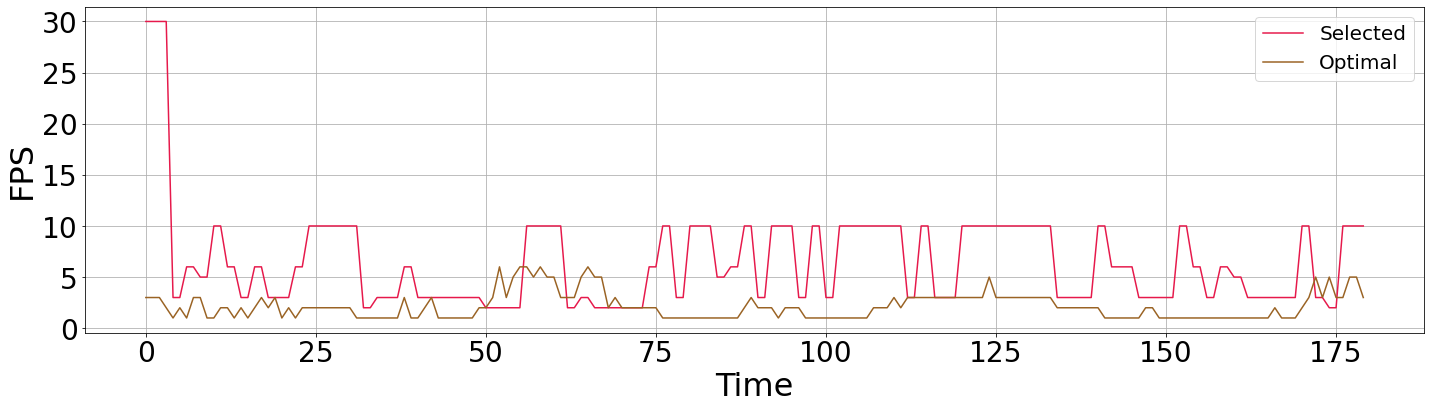

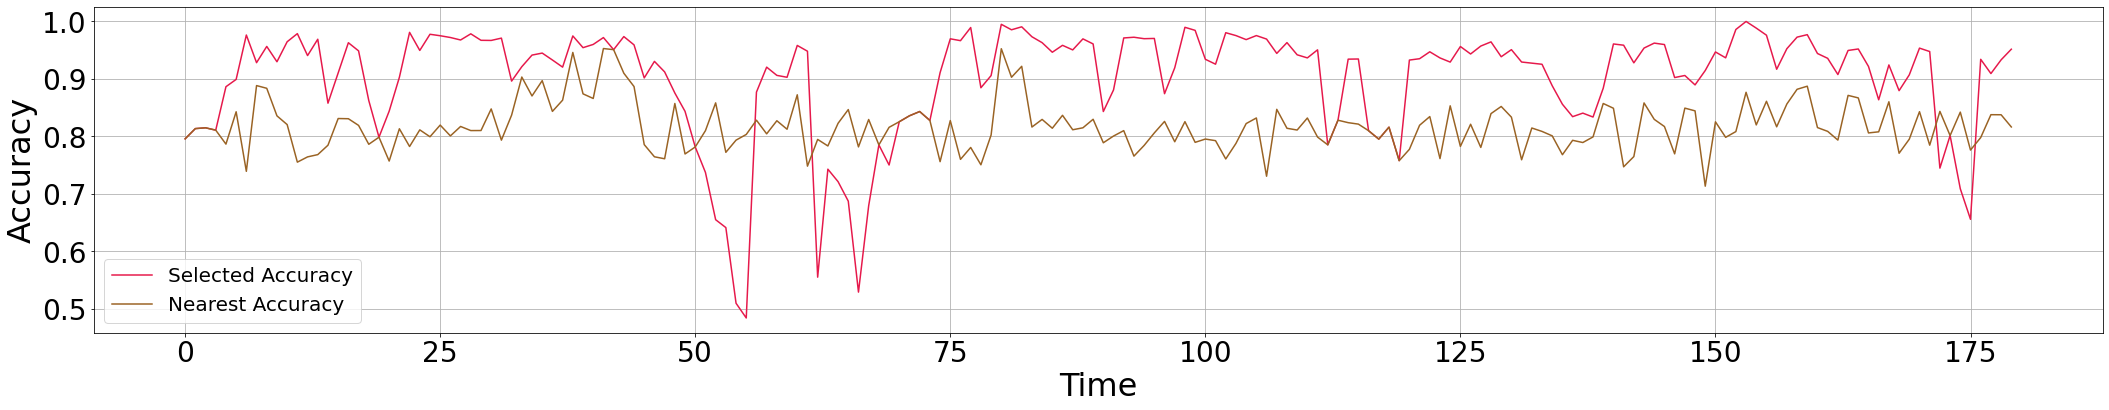


Period: Afternoon
Selected F1 Accuracy: 0.818
Nearest F1 Accuracy: 0.834
Selected Power: 3.897
Nearest Power: 3.623


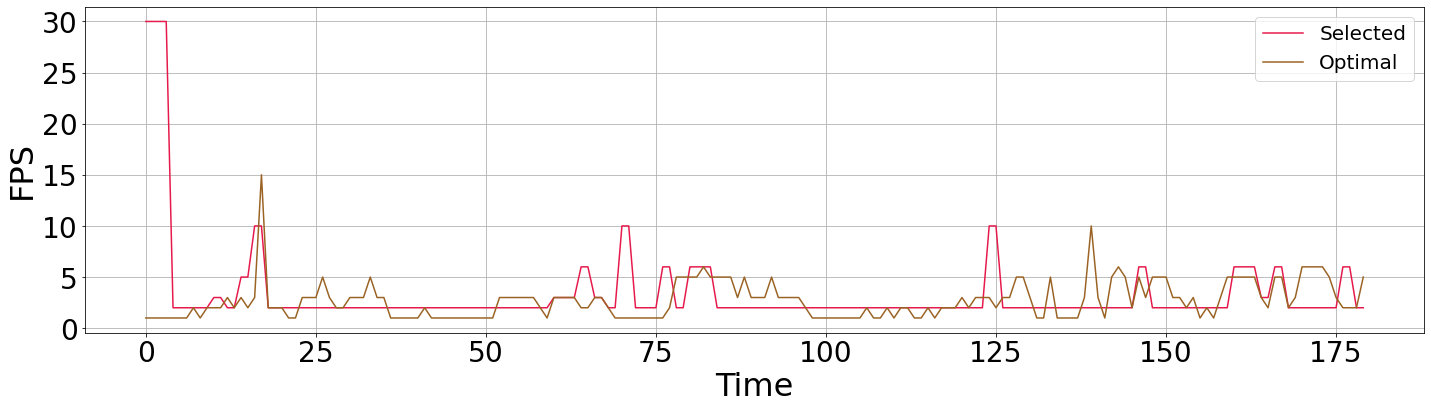

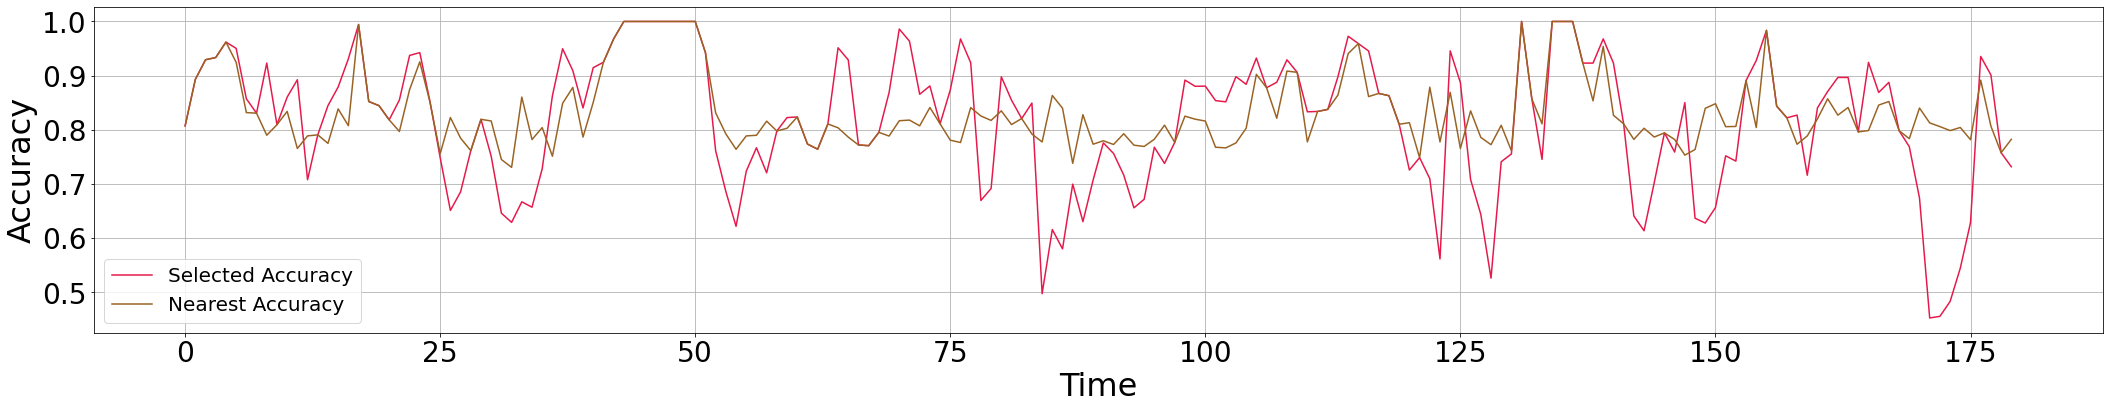


Period: Night
Selected F1 Accuracy: 0.854
Nearest F1 Accuracy: 0.809
Selected Power: 4.852
Nearest Power: 3.976


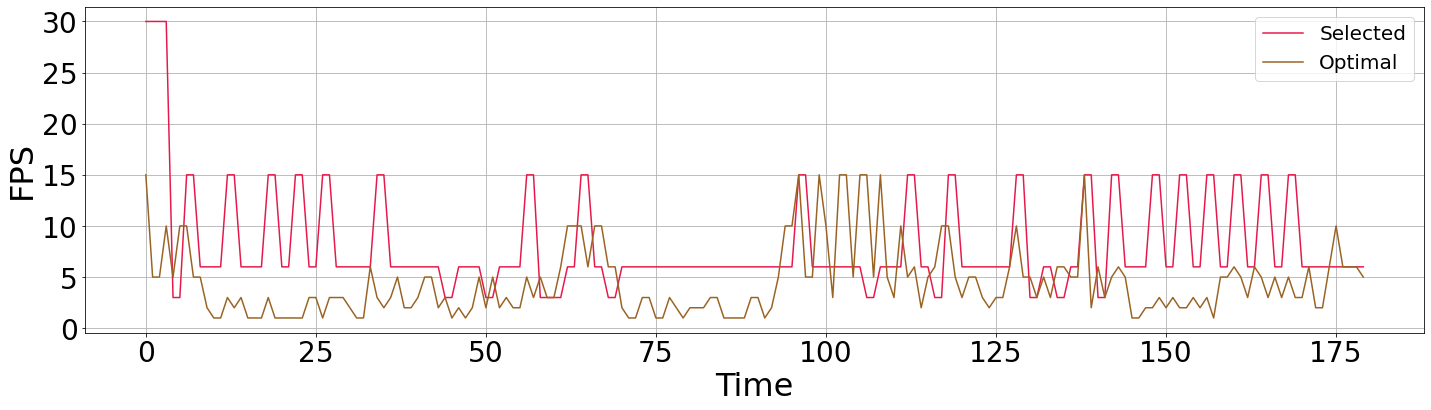

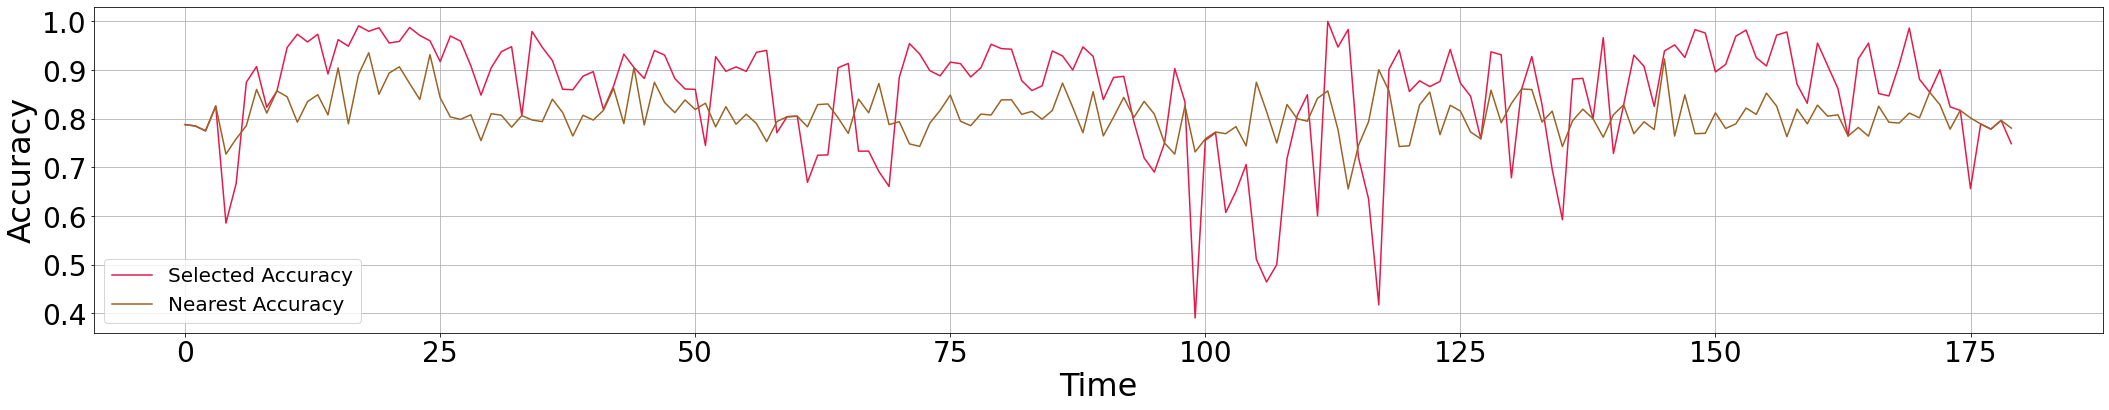

In [33]:
baseline_accuracy = []
eva_accuracy = []
baseline_power = []
eva_power = []
for p in range(len(PERIOD)):
	print(f'Period: {PERIOD[p]}')
	period_video_name = f'{VIDEO_PREFIX}{PERIOD[p]}'

	# Test
	test_length = len(dataset[period_video_name]['30']['x_all'])
	train_index_list = generate_train_index_sets(test_length, sys.maxsize, RP_AMOUNT)

	accuracy_result = load_json_file(os.path.join(plot_directory, period_video_name + "_Accuracy_Result.json"))
	accuracy = extract_metric_list(accuracy_result[CLASS_INDEX], fpss)
	nearest_fps_list = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)

	selected_fps_list_for_accuracy = []
	selected_fps_list_for_power = []
	last_fps = INITIAL_FPS
	train_index_list_idx = 0
	for i in range(test_length):
		if train_index_list_idx < len(train_index_list) and i == train_index_list[train_index_list_idx][0]:
			# Train
			prediction_models = {}
			for fps in fpss:
				prediction_models[fps] = LinearRegression()

			for fps in fpss:
				x_all = dataset[period_video_name][fps]['x_all']
				y_all = dataset[period_video_name][fps]['y_all']

				train_start_idx = train_index_list[train_index_list_idx][0]
				train_end_idx = train_index_list[train_index_list_idx][-1]

				x_train = x_all[train_start_idx : train_end_idx]
				y_train = y_all[train_start_idx : train_end_idx]
						
				prediction_models[fps].fit(x_train, y_train)

		if train_index_list_idx < len(train_index_list) and i in train_index_list[train_index_list_idx]:
			ground_truth_fps = str(nearest_fps_list[i])
			selected_fps_list_for_accuracy.append(ground_truth_fps)
			selected_fps_list_for_power.append(fpss[-1])
			last_fps = ground_truth_fps
			
			if i == train_index_list[train_index_list_idx][-1]:
				train_index_list_idx += 1
			
			continue

		if i % RESAMPLE_RATE != 0:
			selected_fps_list_for_accuracy.append(last_fps)
			selected_fps_list_for_power.append(last_fps)
			continue

		clip_omv_of_fps = dataset[period_video_name][last_fps]['x_all'][i]
		suggested_fps = estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, SAFEGUARD, last_fps)

		last_fps = suggested_fps
		selected_fps_list_for_accuracy.append(last_fps)
		selected_fps_list_for_power.append(last_fps)

	selected_fps_list_for_accuracy = [int(x) for x in selected_fps_list_for_accuracy]
	selected_fps_list_for_power = [int(x) for x in selected_fps_list_for_power]

	selected_accuracy_list = []
	for i in range(test_length):
		selected_throughput = str(selected_fps_list_for_accuracy[i])
		selected_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][selected_throughput]['F1']
		selected_accuracy_list.append(selected_accuracy)
	
	nearest_accuracy_list = []
	for i in range(test_length):
		nearest_throughput = str(nearest_fps_list[i])
		nearest_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][nearest_throughput]['F1']
		nearest_accuracy_list.append(nearest_accuracy)

	power_profile = load_json_file(os.path.join(power_profile_directory))
	max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]

	selected_power_list = []
	for st in selected_fps_list_for_power:
		if str(st) in power_profile:
			selected_power_list.append(power_profile[str(st)])
		else:
			selected_power_list.append(max_power)

	nearest_power_list = []
	for nt in nearest_fps_list:
		if str(nt) in power_profile:
			nearest_power_list.append(power_profile[str(nt)])
		else:
			nearest_power_list.append(max_power)
	
	time = range(test_length)
	print(f'Selected F1 Accuracy: {round(np.mean(np.array(selected_accuracy_list)), 3)}')
	print(f'Nearest F1 Accuracy: {round(np.mean(np.array(nearest_accuracy_list)), 3)}')
	print(f'Selected Power: {round(np.mean(np.array(selected_power_list)), 3)}')
	print(f'Nearest Power: {round(np.mean(np.array(nearest_power_list)), 3)}')

	eva_accuracy.append(round(np.mean(np.array(selected_accuracy_list)), 3))
	baseline_accuracy.append(round(np.mean(np.array(nearest_accuracy_list)), 3))
	eva_power.append(round(np.mean(np.array(selected_power_list)), 3))
	baseline_power.append(round(np.mean(np.array(nearest_power_list)), 3))

	plot_mutiple_lines(time, [selected_fps_list_for_power, nearest_fps_list], 'Time', 'FPS', ['Selected', 'Optimal'], '', (24, 6))
	plot_mutiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))
	# plot_mutiple_lines(time, [selected_power_list, nearest_power_list], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))

	print("")

period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['baseline_accuracy'] = baseline_accuracy
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['eva_accuracy'] = eva_accuracy
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['baseline_power'] = baseline_power
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']['eva_power'] = eva_power

## Re-profiling

Period: Day
Selected F1 Accuracy: 0.893
Nearest F1 Accuracy: 0.817
Selected Power: 4.438
Nearest Power: 3.528


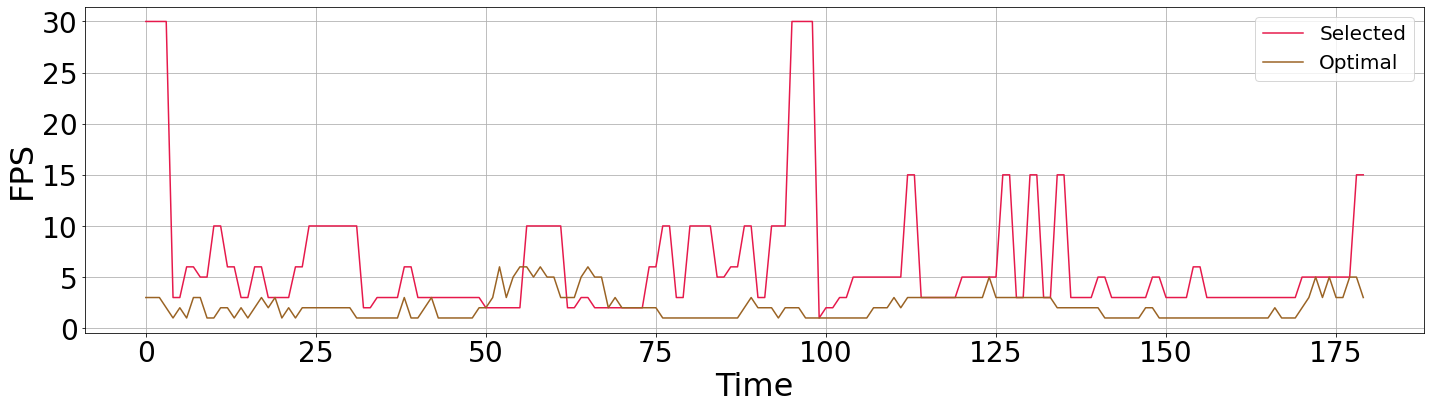

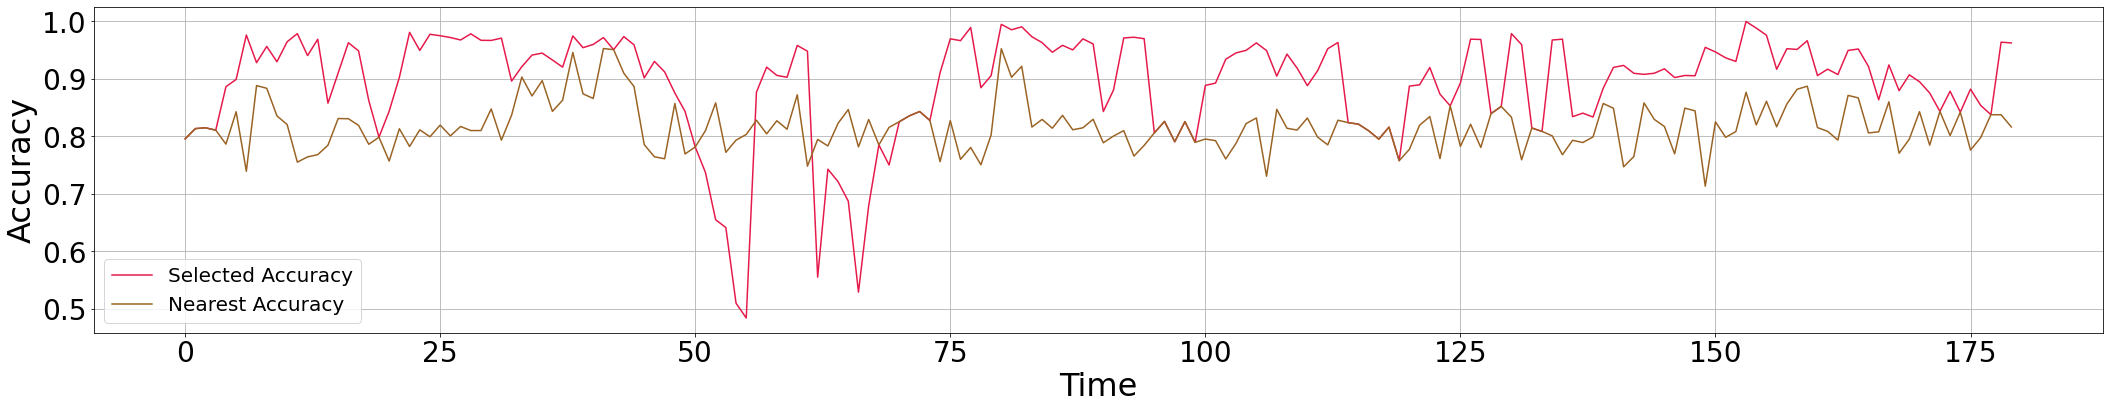


Period: Afternoon
Selected F1 Accuracy: 0.839
Nearest F1 Accuracy: 0.834
Selected Power: 4.171
Nearest Power: 3.623


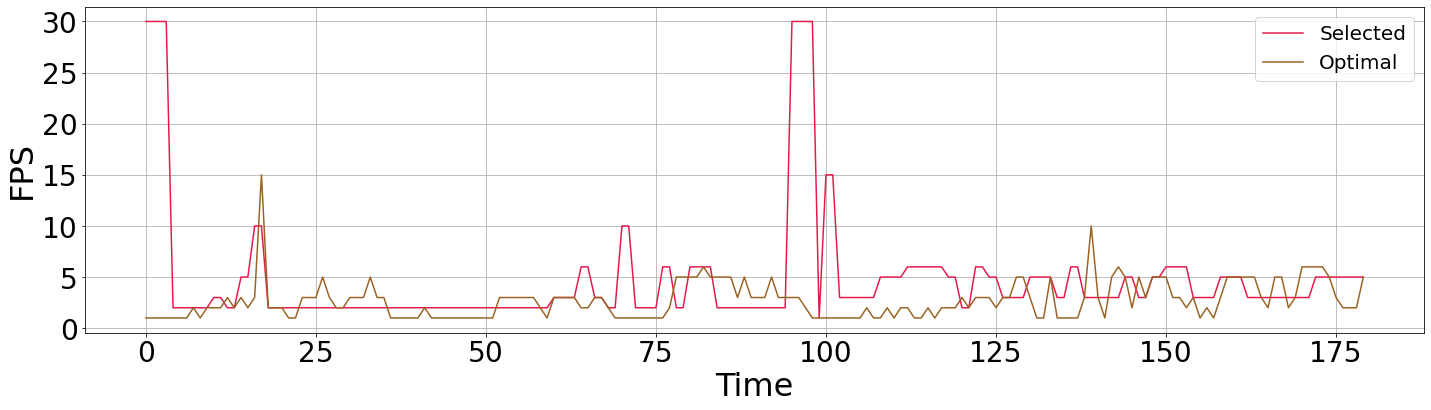

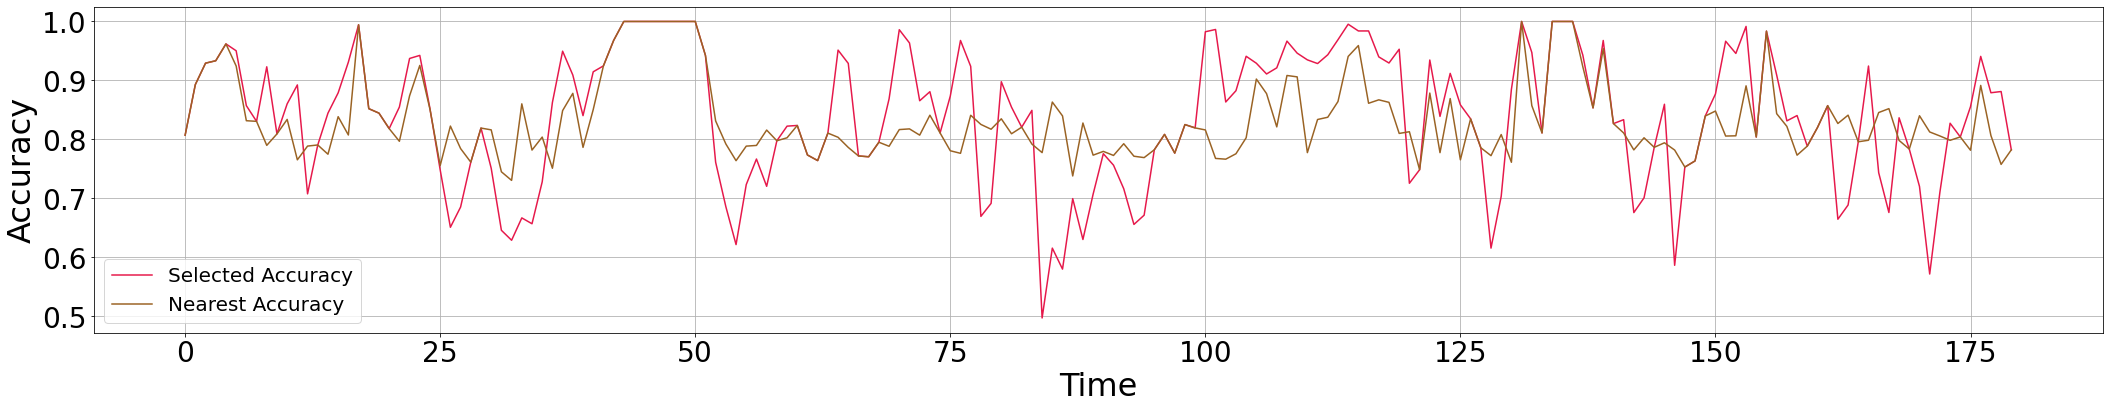


Period: Night
Selected F1 Accuracy: 0.857
Nearest F1 Accuracy: 0.809
Selected Power: 4.924
Nearest Power: 3.976


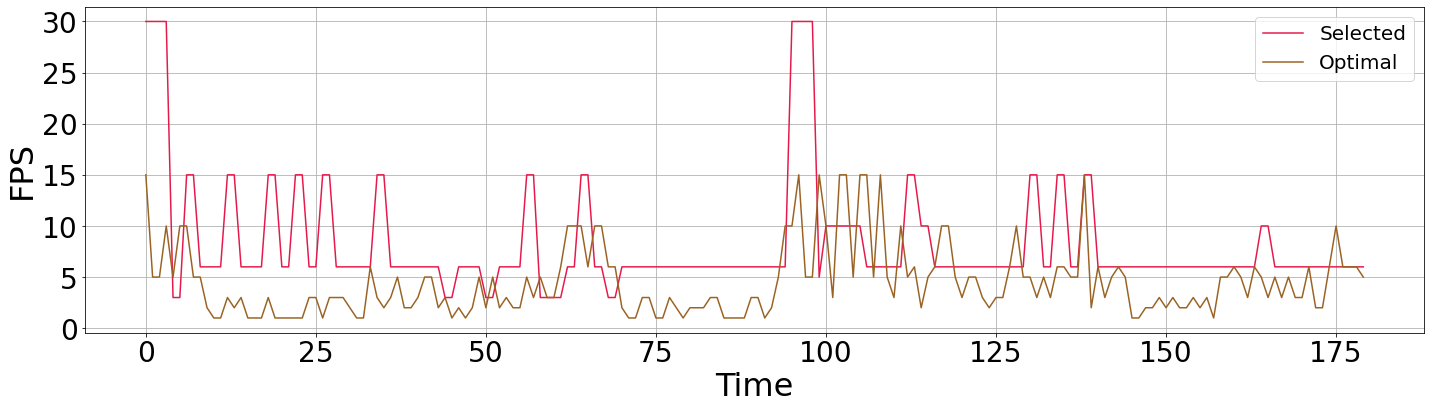

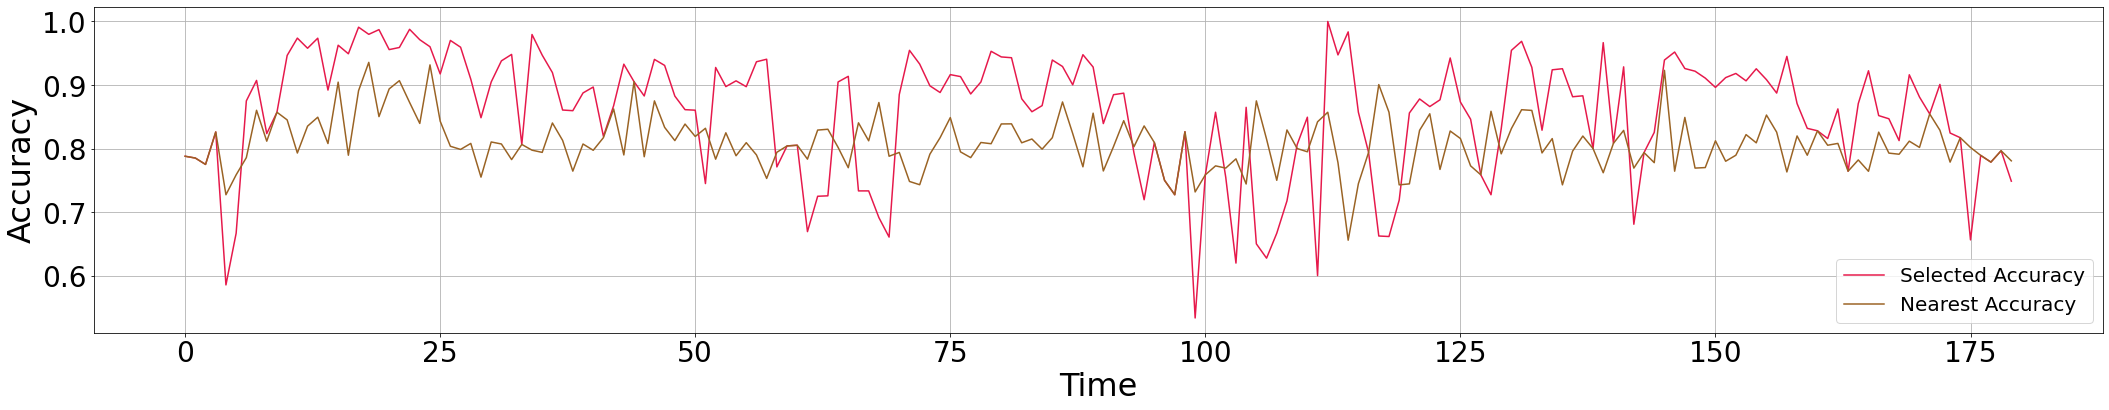

In [34]:
baseline_accuracy = []
eva_accuracy = []
baseline_power = []
eva_power = []
for p in range(len(PERIOD)):
	print(f'Period: {PERIOD[p]}')
	period_video_name = f'{VIDEO_PREFIX}{PERIOD[p]}'

	# Test
	test_length = len(dataset[period_video_name]['30']['x_all'])
	train_index_list = generate_train_index_sets(test_length, RP_PERIOD, RP_AMOUNT)

	accuracy_result = load_json_file(os.path.join(plot_directory, period_video_name + "_Accuracy_Result.json"))
	accuracy = extract_metric_list(accuracy_result[CLASS_INDEX], fpss)
	nearest_fps_list = extract_nearest_fps(accuracy, fpss, TARGET_ACCURACY)

	selected_fps_list_for_accuracy = []
	selected_fps_list_for_power = []
	last_fps = INITIAL_FPS
	train_index_list_idx = 0
	for i in range(test_length):
		if train_index_list_idx < len(train_index_list) and i == train_index_list[train_index_list_idx][0]:
			# Train
			prediction_models = {}
			for fps in fpss:
				prediction_models[fps] = LinearRegression()

			for fps in fpss:
				x_all = dataset[period_video_name][fps]['x_all']
				y_all = dataset[period_video_name][fps]['y_all']

				train_start_idx = train_index_list[train_index_list_idx][0]
				train_end_idx = train_index_list[train_index_list_idx][-1]

				x_train = x_all[train_start_idx : train_end_idx]
				y_train = y_all[train_start_idx : train_end_idx]
						
				prediction_models[fps].fit(x_train, y_train)

		if train_index_list_idx < len(train_index_list) and i in train_index_list[train_index_list_idx]:
			ground_truth_fps = str(nearest_fps_list[i])
			selected_fps_list_for_accuracy.append(ground_truth_fps)
			selected_fps_list_for_power.append(fpss[-1])
			last_fps = ground_truth_fps
			
			if i == train_index_list[train_index_list_idx][-1]:
				train_index_list_idx += 1
			
			continue

		if i % RESAMPLE_RATE != 0:
			selected_fps_list_for_accuracy.append(last_fps)
			selected_fps_list_for_power.append(last_fps)
			continue

		clip_omv_of_fps = dataset[period_video_name][last_fps]['x_all'][i]
		suggested_fps = estimate_best_fps_v3(prediction_models, clip_omv_of_fps, fpss, TARGET_ACCURACY, SAFEGUARD, last_fps)

		last_fps = suggested_fps
		selected_fps_list_for_accuracy.append(last_fps)
		selected_fps_list_for_power.append(last_fps)

	selected_fps_list_for_accuracy = [int(x) for x in selected_fps_list_for_accuracy]
	selected_fps_list_for_power = [int(x) for x in selected_fps_list_for_power]

	selected_accuracy_list = []
	for i in range(test_length):
		selected_throughput = str(selected_fps_list_for_accuracy[i])
		selected_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][selected_throughput]['F1']
		selected_accuracy_list.append(selected_accuracy)
	
	nearest_accuracy_list = []
	for i in range(test_length):
		nearest_throughput = str(nearest_fps_list[i])
		nearest_accuracy = accuracy_result[CLASS_INDEX][i]['metric'][nearest_throughput]['F1']
		nearest_accuracy_list.append(nearest_accuracy)

	power_profile = load_json_file(os.path.join(power_profile_directory))
	max_power = power_profile[str(max([int(k) for k in list(power_profile.keys())]))]

	selected_power_list = []
	for st in selected_fps_list_for_power:
		if str(st) in power_profile:
			selected_power_list.append(power_profile[str(st)])
		else:
			selected_power_list.append(max_power)

	nearest_power_list = []
	for nt in nearest_fps_list:
		if str(nt) in power_profile:
			nearest_power_list.append(power_profile[str(nt)])
		else:
			nearest_power_list.append(max_power)
	
	time = range(test_length)
	print(f'Selected F1 Accuracy: {round(np.mean(np.array(selected_accuracy_list)), 3)}')
	print(f'Nearest F1 Accuracy: {round(np.mean(np.array(nearest_accuracy_list)), 3)}')
	print(f'Selected Power: {round(np.mean(np.array(selected_power_list)), 3)}')
	print(f'Nearest Power: {round(np.mean(np.array(nearest_power_list)), 3)}')

	eva_accuracy.append(round(np.mean(np.array(selected_accuracy_list)), 3))
	baseline_accuracy.append(round(np.mean(np.array(nearest_accuracy_list)), 3))
	eva_power.append(round(np.mean(np.array(selected_power_list)), 3))
	baseline_power.append(round(np.mean(np.array(nearest_power_list)), 3))

	plot_mutiple_lines(time, [selected_fps_list_for_power, nearest_fps_list], 'Time', 'FPS', ['Selected', 'Optimal'], '', (24, 6))
	plot_mutiple_lines(time, [selected_accuracy_list, nearest_accuracy_list], 'Time', 'Accuracy', ['Selected Accuracy', 'Nearest Accuracy'], '', (36, 6))
	# plot_mutiple_lines(time, [selected_power_list, nearest_power_list], 'Time', 'Power', ['Selected Power', 'Nearest Power'], '', (36, 6))

	print("")

period_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['baseline_accuracy'] = baseline_accuracy
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['eva_accuracy'] = eva_accuracy
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['baseline_power'] = baseline_power
period_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']['eva_power'] = eva_power

In [35]:
non_rp_result = period_result[VIDEO_PREFIX][TARGET_ACCURACY]['non_rp']
rp_result = period_result[VIDEO_PREFIX][TARGET_ACCURACY]['rp']

accuracy_yss = [non_rp_result['baseline_accuracy'], non_rp_result['eva_accuracy'], rp_result['eva_accuracy']]
power_yss = [non_rp_result['baseline_power'], non_rp_result['eva_power'], rp_result['eva_power']]

In [36]:
def plot_bar_chart_33(values, categories, subcategories, title, x_label, y_label, y_range, label_size=24, tick_size=16, legend_size=12):
	# Organize data into groups
	data = {
		categories[0]: values[0],
		categories[1]: values[1],
		categories[2]: values[2],
	}

	# Set bar colors for each subcategory
	colors = ['skyblue', 'orange', 'pink']

	# Plot settings
	bar_width = 0.25
	x = np.arange(len(categories))  # Group positions

	fig, ax = plt.subplots()

	# Plot each subgroup
	for i, subcategory in enumerate(subcategories):
		values = [data[cat][i] for cat in categories]
		ax.bar(x + i * bar_width, values, bar_width, label=f'{subcategory}', color=colors[i])

	# Labeling and formatting
	ax.set_xlabel(x_label, fontsize=label_size)
	ax.set_ylabel(y_label, fontsize=label_size)
	ax.set_title(title, fontsize=label_size)
	ax.set_xticks(x + bar_width)
	ax.set_xticklabels(categories, fontsize=tick_size)
	plt.tick_params(axis='y', labelsize=tick_size)
	ax.legend(fontsize=legend_size)

	ax.set_ylim(y_range[0], y_range[1])

	plt.tight_layout()
	plt.show()


In [37]:
def plot_bar_chart_33_with_line(values, categories, subcategories, hline_value, title, x_label, y_label, y_range, label_size=24, tick_size=16, legend_size=12):
	# Organize data into groups
	data = {
		categories[0]: values[0],
		categories[1]: values[1],
		categories[2]: values[2],
	}

	# Set bar colors for each subcategory
	colors = ['skyblue', 'orange', 'pink']

	# Plot settings
	bar_width = 0.25
	x = np.arange(len(categories))  # Group positions

	fig, ax = plt.subplots()

	# Plot each subgroup
	for i, subcategory in enumerate(subcategories):
		values = [data[cat][i] for cat in categories]
		ax.bar(x + i * bar_width, values, bar_width, label=f'{subcategory}', color=colors[i])
	
	ax.axhline(y=hline_value, color='red')

	# Labeling and formatting
	ax.set_xlabel(x_label, fontsize=label_size)
	ax.set_ylabel(y_label, fontsize=label_size)
	ax.set_title(title, fontsize=label_size)
	ax.set_xticks(x + bar_width)
	ax.set_xticklabels(categories, fontsize=tick_size)
	plt.tick_params(axis='y', labelsize=tick_size)
	ax.legend(fontsize=legend_size)

	ax.set_ylim(y_range[0], y_range[1])

	plt.tight_layout()
	plt.show()


In [38]:
def transpose_2d_list(matrix):
	"""
	Transpose a 2D list (matrix).

	Args:
			matrix (list of lists): The 2D list to transpose.

	Returns:
			list of lists: The transposed 2D list.
	"""
	# Use zip with unpacking to transpose the matrix
	return [list(row) for row in zip(*matrix)]

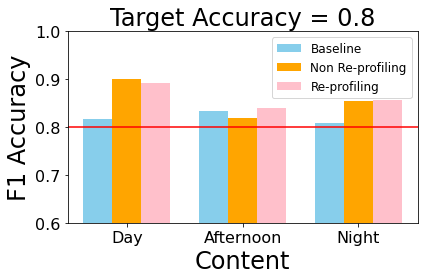

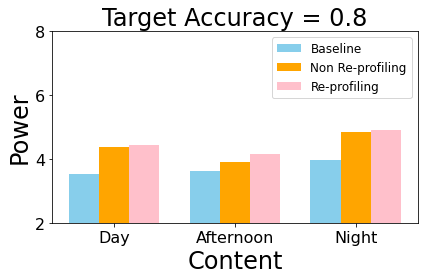

In [40]:
plot_bar_chart_33_with_line(transpose_2d_list(accuracy_yss), ['Day', 'Afternoon', 'Night'], ['Baseline', 'Non Re-profiling', 'Re-profiling'], TARGET_ACCURACY, f'Target Accuracy = {TARGET_ACCURACY}', 'Content', 'F1 Accuracy', (TARGET_ACCURACY-0.2, 1))
plot_bar_chart_33(transpose_2d_list(power_yss), ['Day', 'Afternoon', 'Night'], ['Baseline', 'Non Re-profiling', 'Re-profiling'], f'Target Accuracy = {TARGET_ACCURACY}', 'Content', 'Power', (2, 8))